In [25]:
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt

In [3]:
# Скачиваем файл
URL = "https://77.rosstat.gov.ru/storage/mediabank/Динамика%20денежных%20доходов%20населения%20г.%20Москвы%20за%202014-2024%20гг.(2).xlsx"

r = requests.get(URL, verify=False)
r.raise_for_status()
with open("income.xlsx", "wb") as f:
    f.write(r.content)
print("Файл скачан")



/Users/sabina/mosstat_dashboard/venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '77.rosstat.gov.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Файл скачан


In [4]:
# Читаем Excel
df = pd.read_excel("income.xlsx", skiprows=2)  # пропуск строк с заголовками


In [5]:
# Переименовываем первый столбец
df = df.rename(columns={df.columns[0]: "indicator"})


In [6]:
# Приведение числовых столбцов к float
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(" ", "").str.replace(",", "."), errors="coerce")



In [7]:
# Переводим в длинный формат
df_long = df.melt(id_vars="indicator", var_name="year", value_name="value")
df_long = df_long.dropna()


In [8]:
# Сохраняем для дальнейшей работы
os.makedirs("data/processed", exist_ok=True)
df_long.to_csv("data/processed/income_cleaned.csv", index=False)
print("CSV сохранён")

CSV сохранён


In [10]:
def preprocess_excel(file_path, skiprows=2):
    df = pd.read_excel(file_path, skiprows=skiprows)
    df = df.rename(columns={df.columns[0]: "indicator"})
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(" ", "").str.replace(",", "."), errors="coerce")
    df_long = df.melt(id_vars="indicator", var_name="year", value_name="value")
    df_long = df_long.dropna()
    return df_long

income = preprocess_excel("/Users/sabina/mosstat_dashboard/data/raw/income.xlsx")


In [11]:
import pandas as pd

df = pd.read_csv("data/processed/income_cleaned.csv")
print(df.head())
print(df.info())

                                           indicator  year         value
0                Денежные доходы        (тыс.рублей)  2014  8.089882e+09
1               Потребительские расходы (тыс.рублей)  2014  6.995101e+09
2  Денежные доходы в расчете           на душу на...  2014  5.567049e+04
3  Потребительские расходы            в расчете н...  2014  4.813676e+04
4  Денежные доходы в расчете \nна душу населения,...  2014  9.917227e+01
<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   indicator  88 non-null     str    
 1   year       88 non-null     str    
 2   value      88 non-null     float64
dtypes: float64(1), str(2)
memory usage: 2.2 KB
None


In [12]:
import re

# Оставляем только цифры (год)
df['year'] = df['year'].astype(str).apply(lambda x: int(re.search(r'\d{4}', x).group()))

In [15]:
df = pd.read_excel("/Users/sabina/mosstat_dashboard/data/raw/income.xlsx", skiprows=2)
df = df.rename(columns={df.columns[0]: "indicator"})



In [16]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(" ", "").str.replace(",", "."), errors="coerce")



In [17]:
# Переводим в длинный формат
df_long = df.melt(id_vars="indicator", var_name="year", value_name="value")
df_long = df_long.dropna()



In [18]:
# Чистка года и индикаторов
df_long['year'] = df_long['year'].astype(str).apply(lambda x: int(re.search(r'\d{4}', x).group()))
df_long['indicator'] = df_long['indicator'].str.replace('\n', ' ').str.strip()



In [19]:

# Сохраняем CSV для базы данных
os.makedirs("data/db_ready", exist_ok=True)
df_long.to_csv("data/db_ready/income_for_db.csv", index=False)



In [20]:
# Создание сводной таблицы для анализа
pivot = df_long.pivot(index='year', columns='indicator', values='value')



In [21]:
# Чистим названия столбцов после pivot
pivot.columns = pivot.columns.str.replace('\n', ' ')  # переносы -> пробел
pivot.columns = pivot.columns.str.replace(r'\s+', ' ', regex=True)  # множественные пробелы -> один
pivot.columns = pivot.columns.str.replace(r'\d+\)$', '', regex=True)  # удаляем '3)', '2)' в конце
pivot.columns = pivot.columns.str.strip()  # убираем пробелы по краям

print(pivot.columns)  # проверяем, какие названия теперь

Index(['Денежные доходы (тыс.рублей)',
       'Денежные доходы в расчете на душу населения (рублей в месяц)',
       'Денежные доходы в расчете на душу населения, в % к соответствующему периоду',
       'Потребительские расходы в расчете на душу населения (рублей в месяц)',
       'Потребительские расходы в расчете на душу населения, в % к соответствующему периоду',
       'Потребительские расходы (тыс.рублей)',
       'Реальные денежные доходы в % к соответствующему периоду',
       'Реальные располагаемые денежные доходы в % к соответствующему периоду'],
      dtype='str', name='indicator')


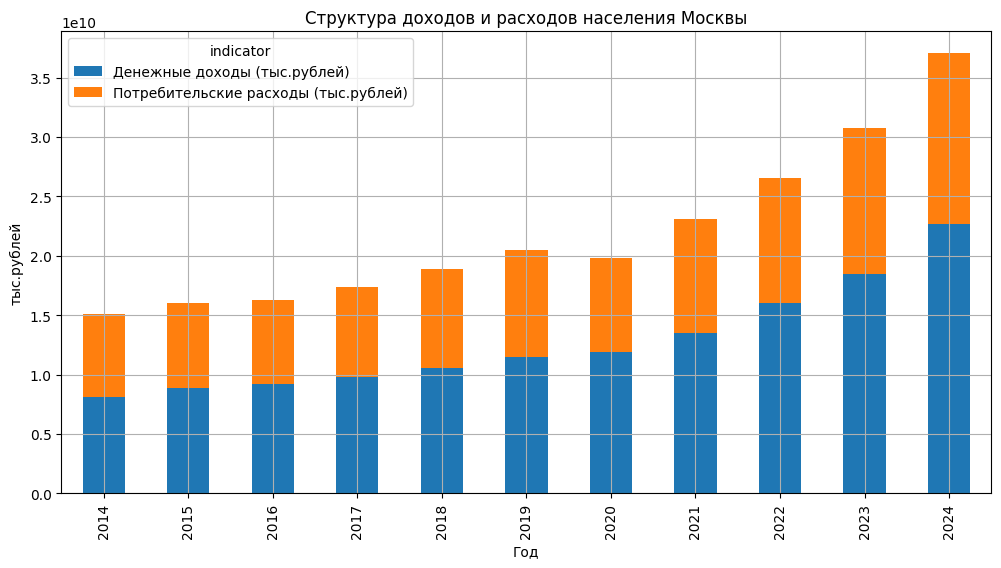

In [27]:
# Пример графика: доходы и расходы в тыс.рублей
pivot[['Денежные доходы (тыс.рублей)', 'Потребительские расходы (тыс.рублей)']].plot(
    kind='bar', stacked=True, figsize=(12,6)
)
plt.title("Структура доходов и расходов населения Москвы")
plt.xlabel("Год")
plt.ylabel("тыс.рублей")
plt.grid(True)
plt.show()

In [31]:
pivot['Разница доходы-расходы (тыс.рублей)'] = (
    pivot['Денежные доходы (тыс.рублей)'] -
    pivot['Потребительские расходы (тыс.рублей)']
)

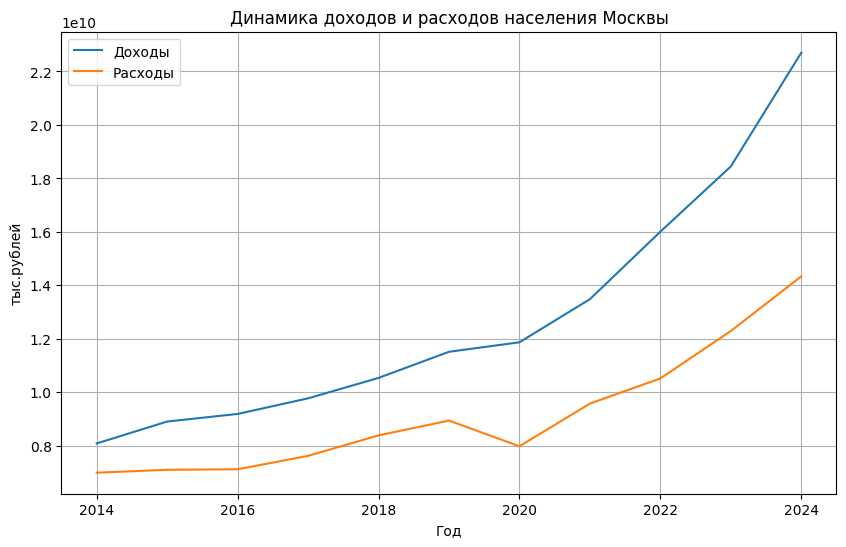

In [35]:
plt.figure(figsize=(10,6))

plt.plot(pivot.index,
         pivot['Денежные доходы (тыс.рублей)'],
         label='Доходы')

plt.plot(pivot.index,
         pivot['Потребительские расходы (тыс.рублей)'],
         label='Расходы')

plt.title("Динамика доходов и расходов населения Москвы")
plt.xlabel("Год")
plt.ylabel("тыс.рублей")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
pivot['Темп роста доходов (%)'] = (
    pivot['Денежные доходы (тыс.рублей)']
    .pct_change() * 100
)

pivot['Темп роста расходов (%)'] = (
    pivot['Потребительские расходы (тыс.рублей)']
    .pct_change() * 100
)

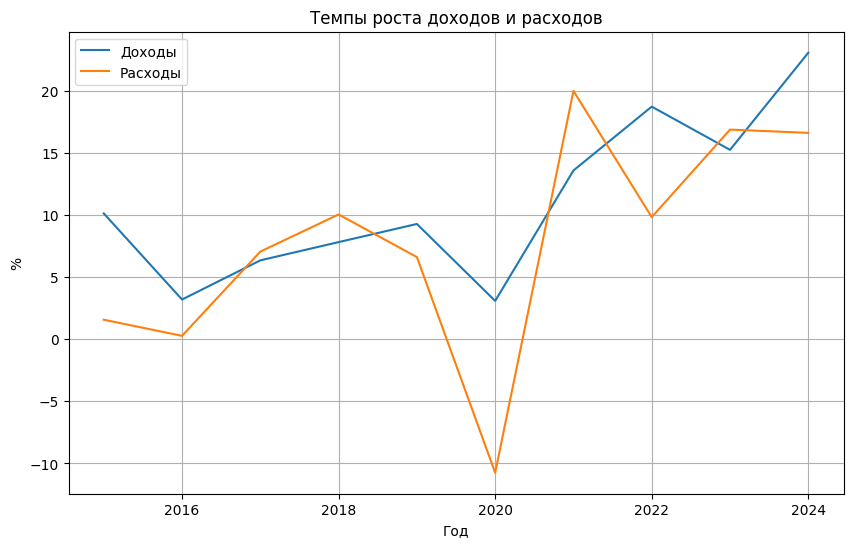

In [34]:
plt.figure(figsize=(10,6))
plt.plot(pivot.index, pivot['Темп роста доходов (%)'], label='Доходы')
plt.plot(pivot.index, pivot['Темп роста расходов (%)'], label='Расходы')
plt.title("Темпы роста доходов и расходов")
plt.xlabel("Год")
plt.ylabel("%")
plt.legend()
plt.grid(True)
plt.show()